<a href="https://colab.research.google.com/github/Andrea68A/Puc_Ciencia_Dados/blob/MVP_Machine_Learning/MVP_dataset_emprestimo_Andrea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sobre o dataset de critérios de classificação para concessão de empréstimos #

O dataset **Loan Approval Classification Dataset** (https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data?select=loan_data.csv) aborda a possibilidade de prever o status de aprovação de empréstimos com base em características demográficas (gênero, escolaridade, idade, renda), financeiras (ex: empréstimos prévios, se o indivíduo é proprietário ou não de imóvel)  e específicas (ex: escore de crédito, percentual de renda comprometida com o empréstimo).





Este dataset possui 45.000 linhas e 14 atributos. Este conjunto de dados permite a classificação binária para concessão de empréstimo, levando em consideração o atributo categórico loan_status (status de aprovação do empréstimo), onde: 1 => aprovado; 0 => rejeitado.





Este projeto consiste em comparar as métricas de diferentes algoritmos de classificação binária, com aprendizado supervisionado. As métricas consideradas são: acurácia, precisão, recall, área da curva AUC-ROC, F1_score, a quantidade de falsos positivos e falsos negativos. Este MVP considerou os seguintes algoritmos: a) RandomForest; b) Árvore C 4.5; c) CART; d) KNN com 5 vizinhos; e) KNN com 3 vizinhos; f) Regressão Logística; g) Naive Bayes e h) Support Vector Machine (SVM).



Álem de comparar as métricas dos algoritmos de classificação, este trabalho possui uma seção de Análise Exploratória de Dados, por meio de gráficos que utilizam as bibliotecas Seaborn e Matplotlib.


O propósito deste trabalho consiste em auxiliar as instituições financeiras a reduzirem os riscos nos processos de concessão de empréstimo.





Mais informações sobre o modelo podem ser obtidas em:  https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data.



## Dicionário de Dados ##

**Obs**: Serão retirados da análise do dataset os registros de pessoas com idade >= 80 anos, pois maiores de 80 anos geralmente não solicitam empréstimo.

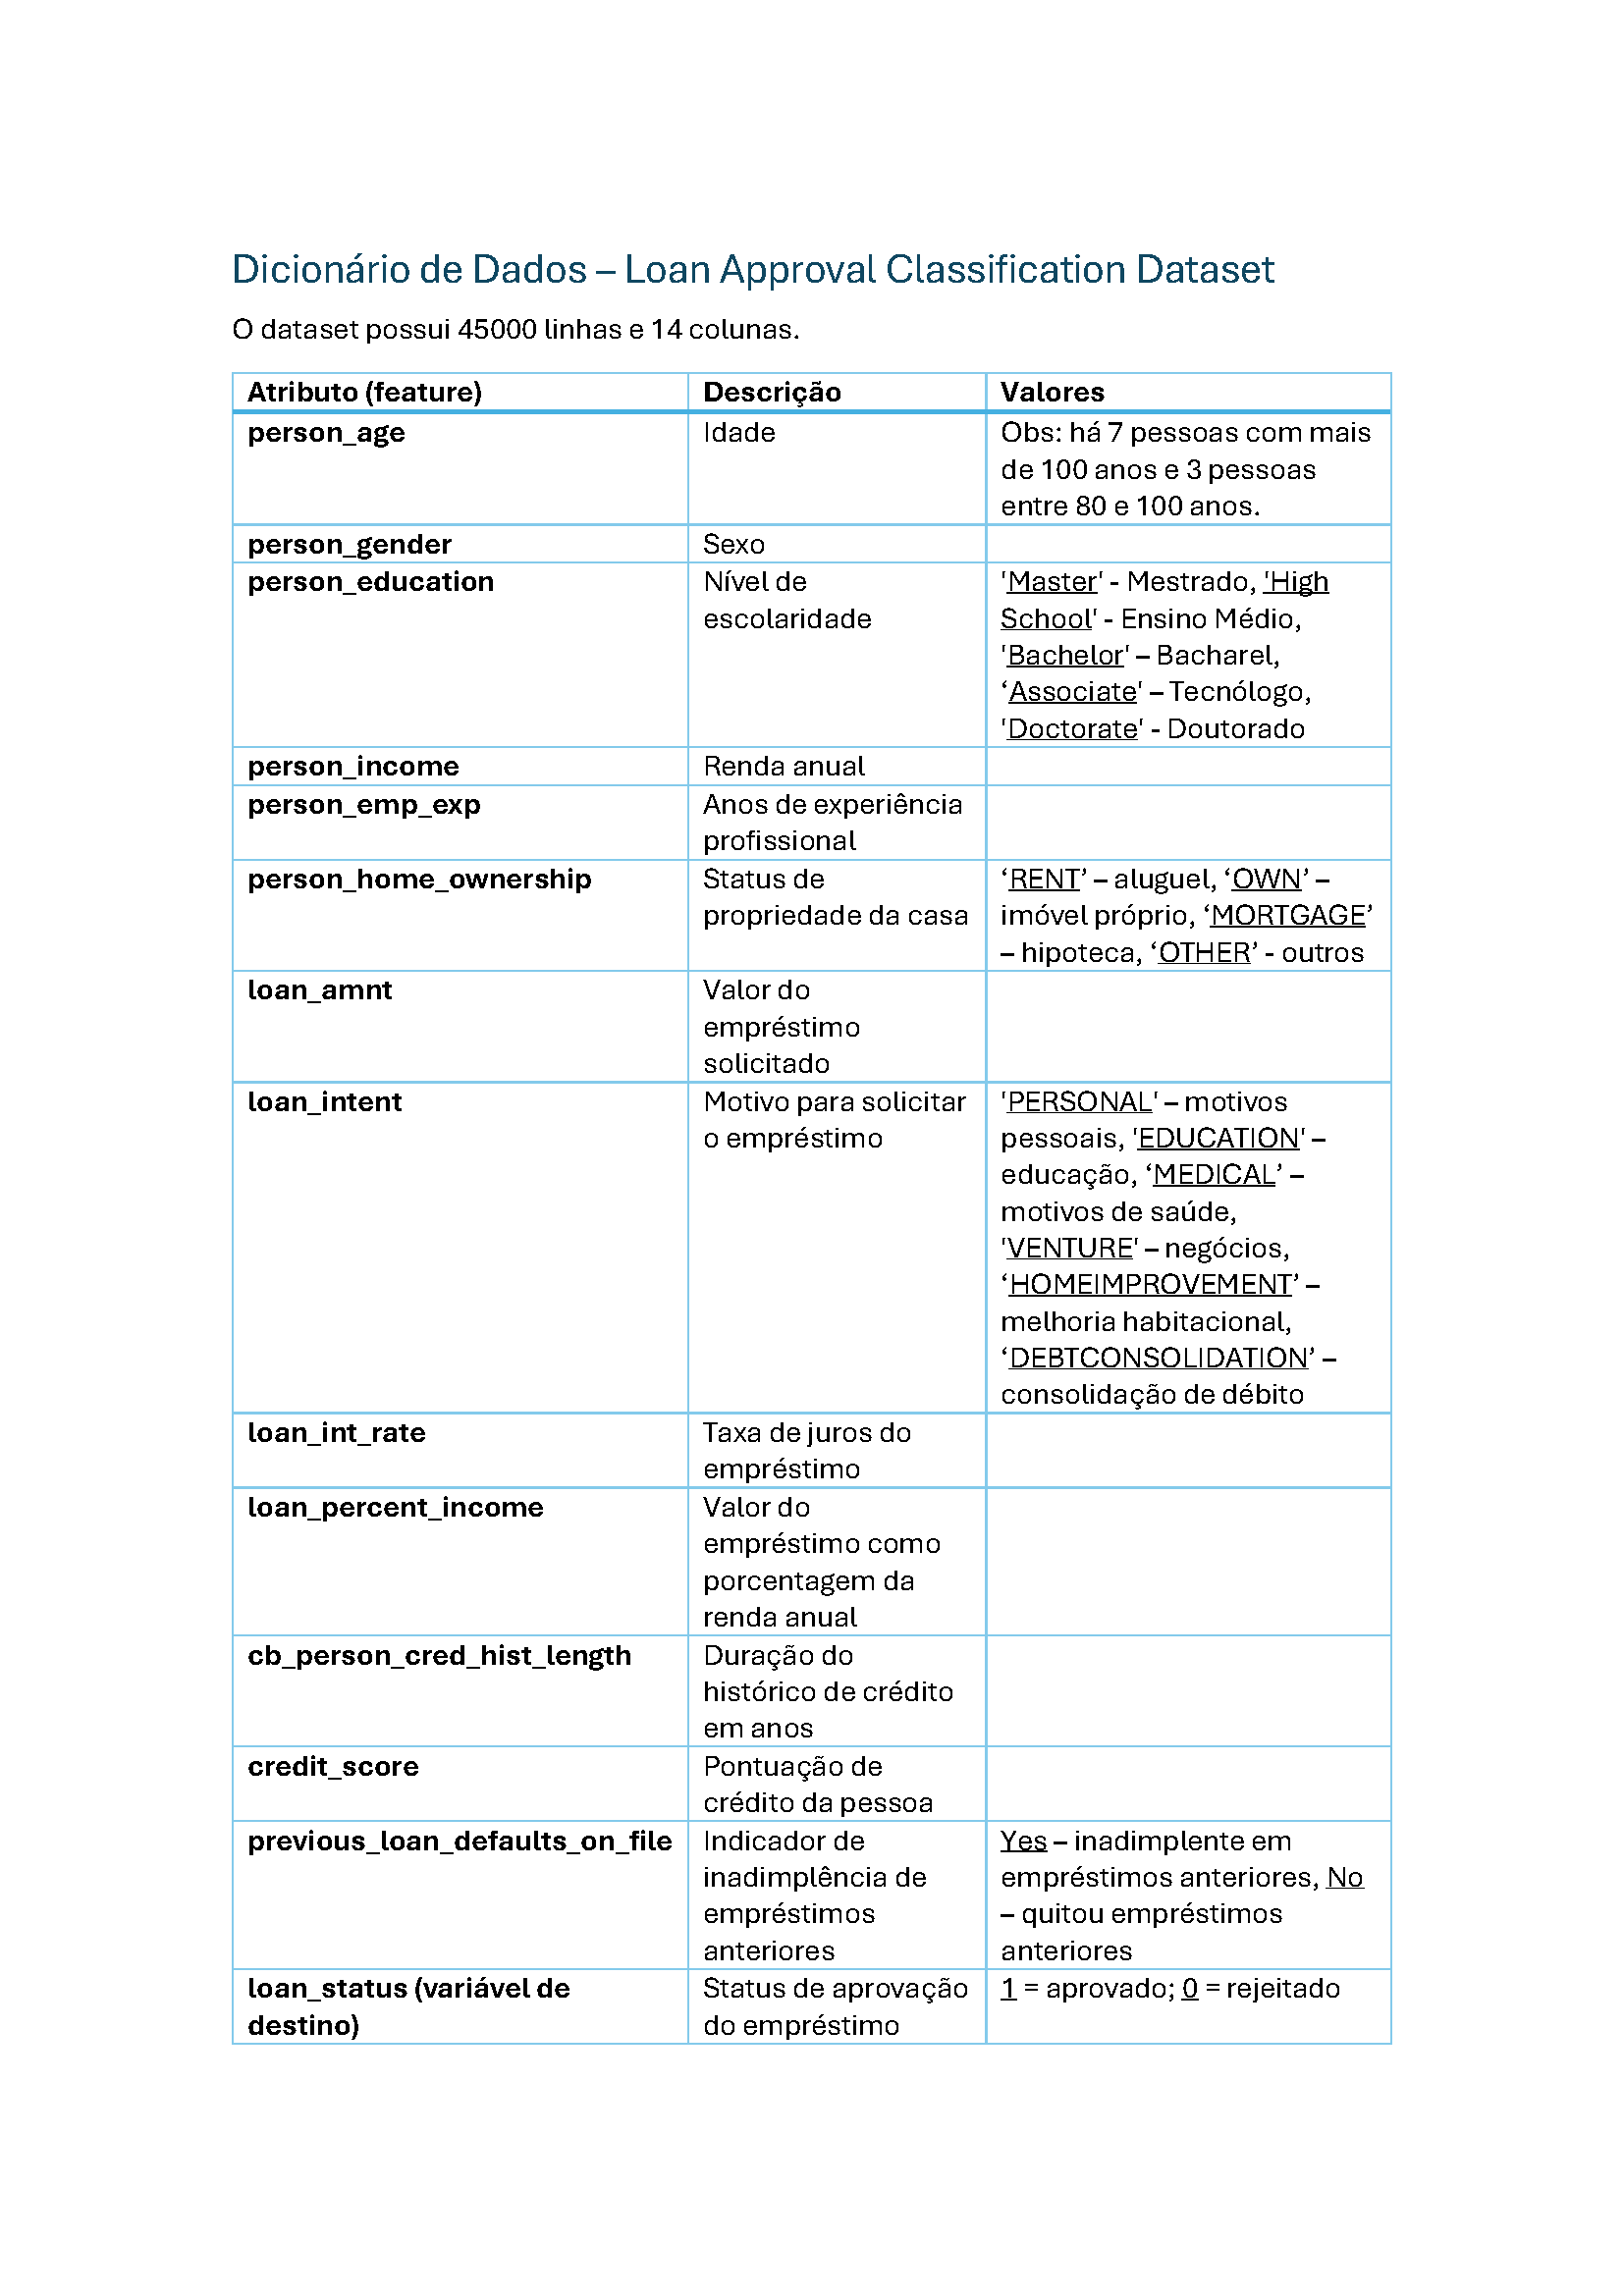



## Imports necessários ##

Para este trabalho, serão utilizadas as seguintes bibliotecas em Python:



- Scikit-Learn - contém os algoritmos, métricas e funções utilizadas em algoritmos de classificação;

- Pandas - utilizada para manipulação de dataset (leitura, escrita) e Análise Exploratória de Dados;

- Numpy - para matrizes, arrays e funções matemáticas

- Seaborn e Matplotlib - para construção de gráficos

- Pandas Profiling  - geração de relatórios que fornecem uma visão geral do dataset, as interações entre variáveis, as correlações, os valores faltantes, uma amostra (primeiros e últimos elementos).





In [ ]:
# Configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder # para codificar variáveis categóricas

from sklearn.model_selection import train_test_split # para particionar em bases de treino e teste (holdout)
from sklearn.model_selection import KFold # para preparar os folds da validação cruzada
from sklearn.model_selection import cross_val_score # para executar a validação cruzada
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, precision_recall_fscore_support, confusion_matrix        # para a exibição da acurácia do modelo
from sklearn.neighbors import KNeighborsClassifier # algoritmo KNN
from sklearn.tree import DecisionTreeClassifier # algoritmo Árvore de Classificação
from sklearn.naive_bayes import GaussianNB # algoritmo Naive Bayes
from sklearn.svm import SVC # algoritmo SVM
from sklearn.linear_model import LogisticRegression # Importando a classe LogisticRegression
from sklearn.ensemble import RandomForestClassifier # Importando a classe RandomForestClassifier
from sklearn.preprocessing import StandardScaler # Para a padronização de dados
from sklearn.preprocessing import MinMaxScaler # Para a normalização de dados, relevante em algoritmo SVM
import seaborn as sns
import time

from seaborn import heatmap
import matplotlib.pyplot as plt



## Carga do dataset e Análise Exploratória dos Dados ##

In [ ]:
# importando dados de uma url para um dataframe

# url a importar

url_dados = 'https://raw.githubusercontent.com/Andrea68A/Puc_Ciencia_Dados/refs/heads/MVP_Machine_Learning/loan_data.csv'


# carga do dataset através da url, com separador de colunas = "," e pulando linhas com erros
emprestimos = pd.read_csv(url_dados, sep =",", on_bad_lines='skip') # pulando linhas com erros




# verificando que emprestimos é um dataframe
print(type(emprestimos))
print()


# Exibição de dados estatísticos sobre o dataset
display(emprestimos.describe())
print()
print()
display(emprestimos.info())


# Exibiição de dados sobre as linhas do dataset
display(emprestimos.head()) # exibe as 5 primeiras linhas
print()
display(emprestimos.tail()) # exibe as 5 últimas linhas
print()



### Tratamento de valores nulos no dataset ###

Este dataset não possui valores nulos.

In [ ]:
# Tratamento de valores nulos

# Verifique valores nulos
print("Coluna", "\t\t\t", "Valores Nulos") #added a comma here
print(emprestimos.isnull().sum())
print('Total de valores nulos no dataset:',emprestimos.isnull().sum().sum())

emprestimos.ffill(inplace=True)  # Exemplo: preenchendo com o método forward fill

### Verificação de idades discrepantes para a concessão de empréstimo ###

No modelo de dados, há 7 pessoas com idade >= 100 anos, sendo 3 registros com idade == 144, 2 linhas com idade == 123, 1 pessoa com 116 anos e 1 linha com idade == 106. Para estes registros discrepantes, há solicitação de empréstimo para pagamentos de despesas educacionais e para abertura de negócios, sendo.
Foram filtrados ("drop") 10 linhas com idade >= 80 anos, por não ser usual que maiores de 80 anos obtenham empréstimos e para eliminar valores discrepantes na análise.
Das 45.000 linhas iniciais, o modelo considerado para a análise passou a ter 44.990 registros.

In [ ]:
# Pessoas maiores de 80 anos - idade discrepante para a concessão de
# empréstimos
emprestimos.loc[(emprestimos["person_age"] >= 80)]

### Remoção de linhas com idade >= 80 ###

In [ ]:
# Serão excluídas as pessoas que possuem idade >= 80
emprestimos = emprestimos.loc[~(emprestimos["person_age"] >=80)]
emprestimos.info()

### Verificação e contagem de valores para atributos do tipo object  ###

In [ ]:
# Verificação e contagem de valores para atributos do tipo object
for categoria in emprestimos.columns:
    if emprestimos[categoria].dtype == 'object':
        print(f"Contadores de valores para a coluna: {categoria}")
        print(emprestimos[categoria].value_counts())
        print("\n")

## Análise Exploratória de Dados - Gráficos ##

### Gráfico de barras - Faixas Etárias por Status de Empréstimo ###

In [ ]:
# Gráfico de barras faixas etárias por status de obtenção de empréstimo
# O gráfico de barras foi agrupado em faixas de idade.
# Considerando a idade máxima para empréstimos == 79 anos

emprestimos["person_age_bins"] = pd.cut(
   emprestimos["person_age"],
    bins = [19, 25, 30, 40, 60, 79],
    labels = ["20-25", "25-30", "30-40", "40-60", "60-79"]
)
# Quantidade de pessoas por grupo de idade
print(emprestimos["person_age_bins"].value_counts())

# Quantidade total de valores nulos para idade <= 79
# A soma de valores nulos corresponde às pessoas que possuem idade >=80
# A soma de valores nulos (que não se enquadram nas faixas de idade do gráfico) é 10.
print("Soma de valores nulos (idades >=80, neste dataset)", emprestimos["person_age_bins"].isnull().sum())

dados_agrupados = emprestimos.groupby(["person_age_bins", "loan_status"]).size().reset_index(name = "cont")

ax = sns.barplot(
    data = dados_agrupados,
    x = "person_age_bins",
    y = "cont",
    hue = "loan_status",
    palette = "viridis"
)

for container in ax.containers: # imprime a quantidade no centro da barra
    ax.bar_label(container, label_type = "center", fontsize = 8)

plt.title("Status de empréstimo por grupo etário", fontsize = 16)
plt.xlabel("Faixas etárias")
plt.ylabel("Quantidade")
plt.legend(title = "Status de empréstimos")
plt.tight_layout()
sns.despine()
plt.show()

A maior solicitação de empréstimos ocorreu na faixa etária de 20 a 25 anos. Nesta faixa de idade, ocorreu a maior rejeição de empréstimos, como também a maior aprovação.

### Categoria de Escore de Crédito X Status do Empréstimo ###

In [ ]:
# credit score
bins = [300, 580, 670, 740, 800, 850]
rotulos = ["Ruim", "Razoável", "Bom", "Muito Bom", "Excelente"]

emprestimos['credit_score_category'] = pd.cut(emprestimos['credit_score'], bins = bins, labels = rotulos)

ax = sns.countplot(
    x = 'credit_score_category',
    hue = 'loan_status',
    data = emprestimos,
    palette='viridis'
)
for container in ax.containers: # imprime a quantidade no centro da barra
    ax.bar_label(container, fontsize = 8)

plt.title("Categoria de escore de crédito por status de empréstimo", fontsize = 16)
plt.legend(title = "Status de emprestimo")
sns.despine()
plt.show()




A maior quantidade de empréstimos aprovados está contida nas categorias Razoável e Bom, ou seja, escores de crédito entre 580 e 740.

### Status (aprovação ou rejeição) do empréstimo por intenção ###

In [ ]:
motivo_emprestimo = emprestimos.groupby(["loan_intent", "loan_status"]).size().reset_index(name = "count")

ax = sns.barplot(
    x = "loan_status",
    y = "count",
    hue = "loan_intent",
    data = motivo_emprestimo

)

for container in ax.containers: # imprime as quantidades por intenção, no centro da barra
    ax.bar_label(container, label_type = "center", fontsize = 8)

plt.title("Status do empréstimo por intenção", fontsize = 16)

plt.ylabel("Quantidade")
plt.xlabel("Status do empréstimo")

handles, labels = plt.gca().get_legend_handles_labels()
labels = [label.capitalize() for label in labels]
plt.legend(handles, labels, title="Propósito do Empréstimo")
plt.title("Status do empréstimo por intenção", fontsize = 16, y = 1.05)

sns.despine()
plt.show()

A maior quantidade de rejeição para obter empréstimos foi para eduação, seguido por abertura de negócios ("Venture").
Os maiores motivos para aceitação de empréstimos foram médicos, seguido por consolidação de débitos.  

### Gráfico de barras - Status de empréstimo por gênero ###

In [ ]:
genero_emprestimo = emprestimos.groupby(["person_gender", "loan_status"]).size().reset_index(name="count")

ax = sns.barplot(
    x="loan_status",
    y="count",
    hue="person_gender",
    data=genero_emprestimo,
    palette="viridis"
)
for container in ax.containers: # imprime as quantidades no centro da barra
    ax.bar_label(container, label_type = "center", fontsize = 8)

plt.ylabel("Quantidade")
plt.xlabel("Status do empréstimo")

handles, labels = plt.gca().get_legend_handles_labels()
labels = [label.capitalize() for label in labels]
plt.legend(handles, labels, title="Gênero")
plt.title("Comparação das taxas de aprovação e rejeição de empréstimos por Gênero", fontsize = 14, y = 1.05)

sns.despine()
plt.show()

O percentual de empréstimos rejeitados por gênero é de aproximadamente 77,8%. O critério de gênero não foi relevante na aprovação ou rejeição do empréstimo.

### Análise Multivariada - gráfico scatterplot ###

Os gráficos scatterplot tiveram que ser separados em variáveis x_var e y_var porque a execução da célula travou, devido à grande quantidade de atributos e linhas.

In [ ]:
# Os gráficos scatterplot tiveram que ser separados em variáveis x_var e y_var porque a execução da célula travou, pois foram
# consideradas 44.990 linhas e 14 atributos para a confecção dos gráficos.
# Para diminuir o processamento, foram gerados 5 gráficos scatterplot


# Scatterplot - credit_score X person_income (renda)
graf = sns.pairplot(emprestimos,hue='loan_status',x_vars='credit_score',y_vars='person_income',palette='viridis',height=4,aspect=12/8) #figsize(12,8) foi atualizada para aspect = 12/8
graf.axes[0,0].set_yscale('log')
plt.show()

# Scatterplot - loan_amnt X person_income
graf2 = sns.pairplot(emprestimos,hue='loan_status',x_vars='loan_amnt',y_vars='person_income',palette='viridis',height=4,aspect=12/8)
graf2.axes[0,0].set_yscale('log')
plt.show()

# Scatterplot - loan_amnt X credit_score
graf3 = sns.pairplot(emprestimos,hue='loan_status',x_vars='loan_amnt',y_vars='credit_score',palette='viridis',height=4, aspect =12/8)
graf3.axes[0,0].set_yscale('log')
plt.show()

# Scatterplot - credit_score X cb_person_cred_hist_lenght
sns.pairplot(emprestimos,hue='loan_status', x_vars='credit_score',y_vars='cb_person_cred_hist_length',palette='viridis',height=4, aspect=12/8)
plt.show()

# Scatterplot - loan_amnt X person_income
graf4 = sns.pairplot(emprestimos,hue='loan_status',x_vars='loan_amnt',y_vars='person_income',palette='viridis',height=4, aspect=12/8)
graf4.axes[0,0].set_yscale('log')
plt.show()

# Scatterplot - loan_int_rate (taxa de juros do empréstimo) X person_income
graf5 = sns.pairplot(emprestimos,hue='loan_status',x_vars='loan_int_rate',y_vars='person_income',palette='viridis',height=4, aspect=12/8)
graf5.axes[0,0].set_yscale('log')
plt.show()

# Scatterplot - loan_amnt X credit_score
sns.pairplot(emprestimos,hue='loan_status',x_vars='loan_amnt',y_vars='credit_score',palette='viridis',height=4, aspect=12/8)
plt.show()

# Scatterplot - credit_score X cb_person_cred_hist_lenght
sns.pairplot(emprestimos,hue='loan_status', x_vars='credit_score',y_vars='cb_person_cred_hist_length',palette='viridis',height=4, aspect=12/8)
plt.show()






Ao analisar os gráficos do tipo scatterplot listados nesta seção, conclui-se que:

- A maior quantidade de empréstimos aprovados possui:
	- escore de crédito entre 500 e 700,
	- tempo de pagamento de empréstimo em até 15 anos,
	- rendimentos anuais entre 10.000 e 500.000,
  - taxa de juros entre 7 e 20%,
	- valores obtidos de empréstimo entre 10.000 e 30.000.



### Boxplot para outliers ###

In [ ]:
# Boxplot para outliers
nomes = [
    "Idade", "Renda Pessoal", "Anos de Experiência Profissional",
    "Valor do Empréstimo", "Taxa de Juros do Empréstimo", "Percentual Renda para Empréstimo", "Escore de Crédito"
]

col_numericas = [
    "person_age", "person_income", "person_emp_exp",
    "loan_amnt", "loan_int_rate", "loan_percent_income", "credit_score"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.subplots_adjust(hspace = 0.3, wspace = 0.3)

axes = axes.flatten()

for i, col in enumerate(col_numericas):
    sns.boxplot(emprestimos[col], ax = axes[i])
    axes[i].set_title(f"Boxplot de {nomes[i]}", fontsize = 10)
    axes[i].set_xlabel(nomes[i])
    axes[i].set_ylabel("")

if len(col_numericas) < len(axes):
    for j in range(len(col_numericas), len(axes)):
        fig.delaxes(axes[j])

sns.despine()
plt.show()

Verificamos que este dataset possui muitos outliers para diferentes features (atributos).

### Histograma por categorias ###

In [ ]:
# Histograma por categorias
nomes = [
    "Situação Residencial", "Propósito do Empréstimo", "Inadimplência em Empréstimos Anteriores",
    "Gênero", "Escolaridade"
]

colunas_categorias = [
    "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file",
    "person_gender", "person_education"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.subplots_adjust(hspace = 1.02, wspace = 0.4)

axes = axes.flatten()

for i, col in enumerate(colunas_categorias):
    sns.countplot(x=col, data=emprestimos, ax=axes[i])
    axes[i].set_title(f"Distribuição de {nomes[i]}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Quantidade")
    axes[i].tick_params(axis = 'x', rotation = 90)

for j in range(len(colunas_categorias), len(axes)):
    fig.delaxes(axes[j])

sns.despine()
plt.show()

### Mapa de calor ###

In [ ]:



# Select only numerical features for the heatmap
numeric_features = emprestimos.select_dtypes(include=np.number)

# Create the heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(numeric_features.corr(), annot=True, cmap="Reds", fmt=".2f", cbar=True)
plt.title("Mapa de Calor - Correlacao")
plt.show()

Há forte correlação positiva (>= 0,80) entre a idade, o tempo de concessão de empréstimo e a experiência de trabalho, ou seja, quanto maior a idade, maiores são os tempos de concessão de empréstimo e a experiência de trabalho. A renda anual tem boa correlação (>= 0,50) com o valor do empréstimo obtido

## Codificação das variáveis categóricas e Feature Engineering ##

In [ ]:
# Codificação de variáveis categoricas
emprestimos = pd.get_dummies(emprestimos, drop_first=False)  # Convertendo variáveis categóricas (object) em variáveis dummies (booleanas)

print(emprestimos.head())
print(emprestimos.info())


In [ ]:
emprestimos.head()

## Padronização de Dados

In [ ]:
# Padronizando os dados

scaler_standard = StandardScaler()
dataset_padronizado = pd.DataFrame(scaler_standard.fit_transform(emprestimos), columns=emprestimos.columns)
dataset_padronizado.head()

## Normalização dos Dados

In [ ]:
# normalizando os dados

scaler_minMax = MinMaxScaler()
data_normalize = pd.DataFrame(scaler_minMax.fit_transform(emprestimos), columns=emprestimos.columns)
data_normalize.head()

## Separação em bases de treino e teste (*holdout*) ##

In [ ]:
# Preparação dos dados

# Separação em bases de treino e teste (holdout)

# Drop de colunas desnecessárias, inclusive da feature alvo (target) loan_status
# As colunas a serem excluídas (drop) têm que estar em uma lista

# Preparação dos dados

# Separação em bases de treino e teste (holdout)

# Drop de colunas desnecessárias, inclusive da feature alvo (target) loan_status

columns_to_drop = [
    'person_age_bins_20-25',
    'person_age_bins_25-30',
    'person_age_bins_30-40',
    'person_age_bins_40-60',
    'person_age_bins_60-79',
    'credit_score_category_Ruim',
    'credit_score_category_Razoável',
    'credit_score_category_Bom',
    'credit_score_category_Muito Bom',
    'credit_score_category_Excelente',
    'person_education_Bachelor',
    'person_education_High School',
    'person_education_Master',
    'person_education_Associate',
    'person_education_Doctorate',
    'loan_status'
]
X = emprestimos.drop(columns=columns_to_drop, axis=1)


y = emprestimos['loan_status']  # classe (target) - loan_status, onde 0 -> empréstimo rejeitado e 1 -> empréstimo concedido

X = pd.get_dummies(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=7) # faz a divisão

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7) # faz o particionamento em 10 folds



## Modelagem e avaliação de acurácia para algoritmos de classificação

 A execução do algoritmo de classificação SVM é bastante lenta para este dataset, pois o mesmo apresenta muitos outliers. As imagens abaixo mostram o tempo de execução da célula sem considerar o algoritmo SVM e com o SVM.

1.   Sem o SVM - tempo: 51 segundos
2.   Com o SVM - tempo: 5 minutos


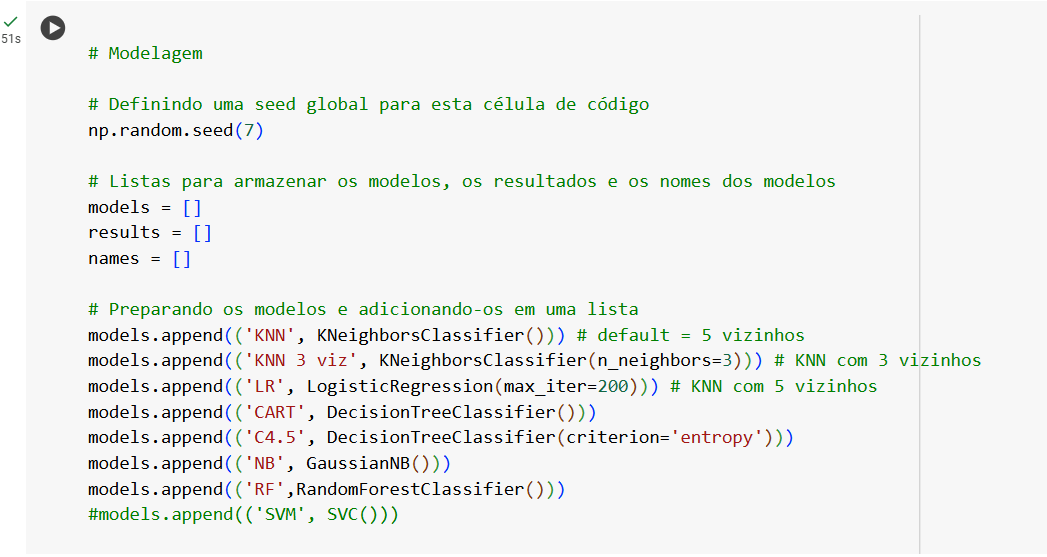


 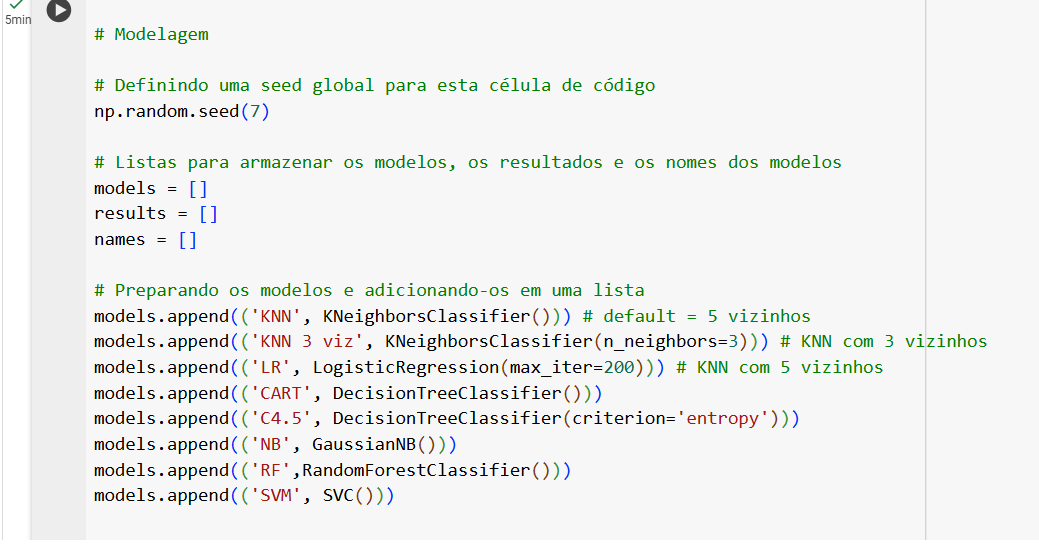



In [ ]:

# Modelagem

# Definindo uma seed global para esta célula de código
np.random.seed(7)

# Listas para armazenar os modelos, os resultados e os nomes dos modelos
models = []
results = []
names = []

# Preparando os modelos e adicionando-os em uma lista
models.append(('KNN', KNeighborsClassifier())) # default = 5 vizinhos
models.append(('KNN 3 viz', KNeighborsClassifier(n_neighbors=3))) # KNN com 3 vizinhos
models.append(('LR', LogisticRegression(max_iter=200))) # KNN com 5 vizinhos
models.append(('CART', DecisionTreeClassifier()))
models.append(('C4.5', DecisionTreeClassifier(criterion='entropy')))
models.append(('NB', GaussianNB()))
models.append(('RF',RandomForestClassifier()))
models.append(('SVM', SVC()))


# Avaliando um modelo por vez
print('A lista abaixo contém o nome dos modelos, com a média de acurácia e o desvio padrão')

for name, model in models:
  tempo_inicial = time.time()
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()) # média e desvio padrão dos 10 resultados da validação cruzada
  tempo_final = time.time()
  tempo_execucao = tempo_final - tempo_inicial
  print(msg, "Tempo de execução em segundos:", tempo_execucao)

# Boxplot de comparação dos modelos
fig = plt.figure()
fig.suptitle('Comparação da Acurácia dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

A lista abaixo contém o nome dos modelos, com a média de acurácia e o desvio padrão
KNN: 0.833241 (0.006843) Tempo de execução em segundos: 12.032546758651733
KNN 3 viz: 0.827712 (0.007344) Tempo de execução em segundos: 12.17237377166748
LR: 0.879390 (0.008584) Tempo de execução em segundos: 13.794580221176147
CART: 0.901033 (0.004442) Tempo de execução em segundos: 2.2177517414093018
C4.5: 0.901673 (0.005765) Tempo de execução em segundos: 2.401747941970825
NB: 0.820210 (0.006127) Tempo de execução em segundos: 0.36983203887939453
RF: 0.927012 (0.002835) Tempo de execução em segundos: 63.818073749542236


## Funções para ajustar modelos, calcular métricas, gerar relatórios de classificação ##

In [ ]:
# Definições de funções, aplicadas para vários algoritmos de classificação
# Funções para:
# 1) ajustar modelo, fazer previsões,
# 2) calcular métricas utilizadas em modelos de classificação binária (acurácia, precisão, recal, AUC_ROC, f1_score)
# 3) imprimir relatório de classificação, matriz de confusão
# 4) exibir mapa de calor da matriz de confusão

def ajustar_modelo(model, X_train, y_train):
    model.fit(X_train, y_train) # ajustando o modelo aos dados
    return model

def fazer_previsoes(model, X_test):
    predictions = model.predict(X_test) # Fazendo as predições com o conjunto de teste
    return predictions

def calcular_acuracia():
    # Estimando a acurácia no conjunto de teste
    acuracia = accuracy_score(y_test, predictions)
    return acuracia

def calcular_precisao():
    # Estimando a precisão no conjunto de teste
    # A precisão é a razão tp / (tp + fp) onde tp é o número de verdadeiros positivos e fp o número de falsos positivos.
    # A precisão é intuitivamente a capacidade do classificador de não rotular como positiva uma amostra negativa.
    # O melhor valor é 1 e o pior valor é 0.
    precisao = precision_score(y_test, predictions)
    return precisao

def calcular_recall():
    # Estimando o recall no conjunto de teste
    # O recall também é conhecido como a taxa de verdadeiros positivos.
    #Representa a razão tp / (tp + fn) onde tp é o número de verdadeiros positivos e fn o número de falsos negativos.
    # O recall é a capacidade do classificador de encontrar todas as amostras positivas.
    # O melhor valor é 1 e o pior valor é 0.
    recall = recall_score(y_test, predictions)
    return recall

def calcular_AUC_ROC():
    # computar área sob a curva ROC (ROC AUC)
    # A AUC-ROC é uma métrica que avalia o desempenho de modelos de classificação binária em diferentes limites de decisão.
    # A AUC-ROC mede a área sob a curva da Taxa de Verdadeiros Positivos (Recall) em função da Taxa de Falsos Positivos.
    # Quanto maior a AUC-ROC, melhor o modelo está em separar as classes
    auc_roc = roc_auc_score(y_test, predictions)
    return auc_roc

def calcular_f1_score():
    # O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
    return f1_score(y_test, predictions)

def imprimir_relatorio_classificacao():
    print('\n\n\tRelatório de classificação\n\n')
    return classification_report(y_test, predictions)

def imprimir_matriz_confusao():
    #"""

    # Returns:

    # """
    matriz_confusao = confusion_matrix(y_test, predictions)
    print('\n\nMatriz de confusao\n\n', matriz_confusao,'\n\n')

    # matriz_confusao[0][0] - verdadadeiros negativos
    # matriz_confusao[0][1] - falsos positivos
    # matriz confusao[1][0] - falsos negativos
    # matriz confusao[1][1] - verdadadeiros positivo
    # Referência para matriz de confusão em:
    # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

    #Imprimindo os valores da matriz de confusão

    print('matriz_confusao[0][0] =', matriz_confusao[0][0], 'Verdadeiros Negativos')
    print('matriz_confusao[0][1] =', matriz_confusao[0][1], 'Falsos Positivos')
    print('matriz_confusao[1][0] =', matriz_confusao[1][0], 'Falsos Negativos')
    print('matriz_confusao[1][1] =', matriz_confusao[1][1], 'Verdadeiros Positivos')

    return matriz_confusao

def exibir_mapa_de_calor(matriz_confusao):
    # Mapa de calor da matriz de confusão

    plt.figure(figsize=(6, 4))
    sns.heatmap(matriz_confusao, annot=True,cmap="Reds",fmt="d", cbar=True)
    plt.title("\n\nMapa de Calor - Matriz de Confusão - Status Empréstimo (aprovado ou rejeitado)\n\n", fontsize=12)
    plt.show()
    return

## Criação de modelos com todo o conjunto de treino ##

### RandomForestClassifier ###

In [ ]:
# Criando um modelo com todo o conjunto de treino
# O modelo RandomForestClassifier apresentou melhores acurácia média e mediana

model = RandomForestClassifier()

model = ajustar_modelo(model, X_train, y_train)
predictions = fazer_previsoes(model, X_test)

# Estimando a acurácia no conjunto de teste
acuracia_modelo_dados = calcular_acuracia()
print(f"Acurácia: {acuracia_modelo_dados:.4%}")

# Estimando a precisão no conjunto de teste
precisao = calcular_precisao()
print(f"Precisão: {precisao:.4%}")

# Estimando o recall no conjunto de teste
recall = calcular_recall()
print(f"Recall: {recall:.4%}")

# Computando a área sob a Curva ROC no conjunto de testes
auc_roc = calcular_AUC_ROC()
print(f"AUC-ROC: {auc_roc:.4}")

# O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
f1 = calcular_f1_score()
print(f"F1_Score: {f1:.4%}")

relatorio_classificacao = imprimir_relatorio_classificacao()
print(relatorio_classificacao)

matriz_confusao = imprimir_matriz_confusao()




# Mapa de calor da matriz de confusão

exibir_mapa_de_calor(matriz_confusao)


### Árvore C4.5 ###

In [ ]:
# Criando um modelo com todo o conjunto de treino
# Métricas para o modelo Árvore C4.5
model = DecisionTreeClassifier(criterion='entropy')

model = ajustar_modelo(model, X_train, y_train)
predictions = fazer_previsoes(model, X_test)

# Estimando a acurácia no conjunto de teste
acuracia_modelo_dados = calcular_acuracia()
print(f"Acurácia: {acuracia_modelo_dados:.4%}")

# Estimando a precisão no conjunto de teste
precisao = calcular_precisao()
print(f"Precisão: {precisao:.4%}")

# Estimando o recall no conjunto de teste
recall = calcular_recall()
print(f"Recall: {recall:.4%}")

# Computando a área sob a Curva ROC no conjunto de testes
auc_roc = calcular_AUC_ROC()
print(f"AUC-ROC: {auc_roc:.4}")

# O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
f1 = calcular_f1_score()
print(f"F1_Score: {f1:.4%}")

relatorio_classificacao = imprimir_relatorio_classificacao()
print(relatorio_classificacao)

matriz_confusao = imprimir_matriz_confusao()

# Mapa de calor da matriz de confusão
exibir_mapa_de_calor(matriz_confusao)



### CART (DecisionTreeClassifier) ###

In [ ]:
# Criando um modelo com todo o conjunto de treino
# Métricas para o modelo CART
model = DecisionTreeClassifier()

model = ajustar_modelo(model, X_train, y_train)
predictions = fazer_previsoes(model, X_test)

# Estimando a acurácia no conjunto de teste
acuracia_modelo_dados = calcular_acuracia()
print(f"Acurácia: {acuracia_modelo_dados:.4%}")

# Estimando a precisão no conjunto de teste
precisao = calcular_precisao()
print(f"Precisão: {precisao:.4%}")

# Estimando o recall no conjunto de teste
recall = calcular_recall()
print(f"Recall: {recall:.4%}")

# Computando a área sob a Curva ROC no conjunto de testes
auc_roc = calcular_AUC_ROC()
print(f"AUC-ROC: {auc_roc:.4}")

# O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
f1 = calcular_f1_score()
print(f"F1_Score: {f1:.4%}")

relatorio_classificacao = imprimir_relatorio_classificacao()
print(relatorio_classificacao)

matriz_confusao = imprimir_matriz_confusao()



# Mapa de calor da matriz de confusão
exibir_mapa_de_calor(matriz_confusao)



### KNN com 5 vizinhos (default) ###

In [ ]:
# Criando um modelo com todo o conjunto de treino
# Métricas para o modelo KNN - o valor default são 5 vizinhos
model = model = KNeighborsClassifier()

model = ajustar_modelo(model, X_train, y_train)
predictions = fazer_previsoes(model, X_test)

# Estimando a acurácia no conjunto de teste
acuracia_modelo_dados = calcular_acuracia()
print(f"Acurácia: {acuracia_modelo_dados:.4%}")

# Estimando a precisão no conjunto de teste
precisao = calcular_precisao()
print(f"Precisão: {precisao:.4%}")

# Estimando o recall no conjunto de teste
recall = calcular_recall()
print(f"Recall: {recall:.4%}")

# Computando a área sob a Curva ROC no conjunto de testes
auc_roc = calcular_AUC_ROC()
print(f"AUC-ROC: {auc_roc:.4}")

# O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
f1 = calcular_f1_score()
print(f"F1_Score: {f1:.4%}")

relatorio_classificacao = imprimir_relatorio_classificacao()
print(relatorio_classificacao)

matriz_confusao = imprimir_matriz_confusao()

# Mapa de calor da matriz de confusão
exibir_mapa_de_calor(matriz_confusao)



### KNN com 3 vizinhos ###

In [ ]:
# Criando um modelo com todo o conjunto de treino
# Métricas para o modelo KNN com 3 vizinhos
model = KNeighborsClassifier(n_neighbors=3)


model = ajustar_modelo(model, X_train, y_train)
predictions = fazer_previsoes(model, X_test)

# Estimando a acurácia no conjunto de teste
acuracia_modelo_dados = calcular_acuracia()
print(f"Acurácia: {acuracia_modelo_dados:.4%}")

# Estimando a precisão no conjunto de teste
precisao = calcular_precisao()
print(f"Precisão: {precisao:.4%}")

# Estimando o recall no conjunto de teste
recall = calcular_recall()
print(f"Recall: {recall:.4%}")

# Computando a área sob a Curva ROC no conjunto de testes
auc_roc = calcular_AUC_ROC()
print(f"AUC-ROC: {auc_roc:.4}")

# O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
f1 = calcular_f1_score()
print(f"F1_Score: {f1:.4%}")

relatorio_classificacao = imprimir_relatorio_classificacao()
print(relatorio_classificacao)

matriz_confusao = imprimir_matriz_confusao()

#Imprimindo os valores da matriz de confusão

# print('matriz_confusao[0][0] =', matriz_confusao[0][0], 'Verdadeiros Negativos')
# print('matriz_confusao[0][1] =', matriz_confusao[0][1], 'Falsos Positivos')
# print('matriz_confusao[1][0] =', matriz_confusao[1][0], 'Falsos Negativos')
# print('matriz_confusao[1][1] =', matriz_confusao[1][1], 'Verdadeiros Positivos')

# Mapa de calor da matriz de confusão

exibir_mapa_de_calor(matriz_confusao)

### Modelo de Regressão Logística ###

In [ ]:
# Criando um modelo com todo o conjunto de treino
# Foi escolhido o modelo Regressão Logística (LR)
model = LogisticRegression(max_iter=200)


model = ajustar_modelo(model, X_train, y_train)
predictions = fazer_previsoes(model, X_test)

# Estimando a acurácia no conjunto de teste
acuracia_modelo_dados = calcular_acuracia()
print(f"Acurácia: {acuracia_modelo_dados:.4%}")

# Estimando a precisão no conjunto de teste
precisao = calcular_precisao()
print(f"Precisão: {precisao:.4%}")

# Estimando o recall no conjunto de teste
recall = calcular_recall()
print(f"Recall: {recall:.4%}")

# Computando a área sob a Curva ROC no conjunto de testes
auc_roc = calcular_AUC_ROC()
print(f"AUC-ROC: {auc_roc:.4}")

# O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
f1 = calcular_f1_score()
print(f"F1_Score: {f1:.4%}")

relatorio_classificacao = imprimir_relatorio_classificacao()
print(relatorio_classificacao)

matriz_confusao = imprimir_matriz_confusao()

# Mapa de calor da matriz de confusão

exibir_mapa_de_calor(matriz_confusao)

### Naive Bayes ###

In [ ]:
# Criando um modelo com todo o conjunto de treino
# Modelo Naive Bayes - GaussianNB()

model =  GaussianNB()


model = ajustar_modelo(model, X_train, y_train)
predictions = fazer_previsoes(model, X_test)

# Estimando a acurácia no conjunto de teste
acuracia_modelo_dados = calcular_acuracia()
print(f"Acurácia: {acuracia_modelo_dados:.4%}")

# Estimando a precisão no conjunto de teste
precisao = calcular_precisao()
print(f"Precisão: {precisao:.4%}")

# Estimando o recall no conjunto de teste
recall = calcular_recall()
print(f"Recall: {recall:.4%}")

# Computando a área sob a Curva ROC no conjunto de testes
auc_roc = calcular_AUC_ROC()
print(f"AUC-ROC: {auc_roc:.4}")

# O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
f1 = calcular_f1_score()
print(f"F1_Score: {f1:.4%}")

relatorio_classificacao = imprimir_relatorio_classificacao()
print(relatorio_classificacao)

matriz_confusao = imprimir_matriz_confusao()

# Exibir mapa de calor da matriz de confusão
exibir_mapa_de_calor(matriz_confusao)


### Support Vector Machine (SVM) ###

In [ ]:
# Criando um modelo com todo o conjunto de treino
# Modelo SVM - SVC

model =  SVC()


model = ajustar_modelo(model, X_train, y_train)
predictions = fazer_previsoes(model, X_test)

# Estimando a acurácia no conjunto de teste
acuracia_modelo_dados = calcular_acuracia()
print(f"Acurácia: {acuracia_modelo_dados:.4%}")

# Estimando a precisão no conjunto de teste
precisao = calcular_precisao()
print(f"Precisão: {precisao:.4%}")

# Estimando o recall no conjunto de teste
recall = calcular_recall()
print(f"Recall: {recall:.4%}")

# Computando a área sob a Curva ROC no conjunto de testes
auc_roc = calcular_AUC_ROC()
print(f"AUC-ROC: {auc_roc:.4}")

# O F1_Score é a média harmônica entre a precisão e o recall.É usado em conjuntos de dados desbalanceados.
f1 = calcular_f1_score()
print(f"F1_Score: {f1:.4%}")

relatorio_classificacao = imprimir_relatorio_classificacao()
print(relatorio_classificacao)

matriz_confusao = imprimir_matriz_confusao()


# Mapa de calor da matriz de confusão

exibir_mapa_de_calor(matriz_confusao)


## Instalação do Pandas Profiling para gerar relatórios ##

Instalação do Pandas Profiling para gerar relatórios que fornecem uma visão geral do dataset, as interações entre variáveis, as correlações, os valores faltantes, uma amostra (primeiros e últimos elementos).

In [ ]:
# Instalando  pandas profiling (executar apenas na 1a vez, depois comentar esta linha)
! pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip

# imports necessários
import numpy as np
import pandas as pd
from pandas_profiling import ProfileReport #import para geração de relatórios

# geração do report
profile = ProfileReport(emprestimos, title='Pandas Profiling Report', html={'style':{'full_width':False}})
profile.to_notebook_iframe()

## Conclusões ##

### Alguns Achados

* A maior quantidade de empréstimos aprovados possui:
	* escore de crédito entre 500 e 700,
	* tempo de pagamento de empréstimo em até 15 anos,
	* rendimentos anuais entre 10.000 e 500.000,
	* taxa de juros entre 7 e 20%,
	* valores obtidos de empréstimo entre 10.000 e 30.000.

* A maior quantidade de rejeição para obter empréstimos foi para eduação, seguido por abertura de negócios ("Venture"). Os maiores motivos para aceitação de empréstimos foram médicos, seguido por consolidação de débitos.

* A faixa etária que mais solicita empréstimo está compreendida entre 20 e 25 anos e possui os maiores índices tanto de aprovação quanto de rejeição.

* O modelo possui muitos outliers, para diversos features (atributos). Portanto, o uso do algoritmo Support Vector Machine (SVM) torna-se extremamente lento.







### Conclusões sobre os algoritmos de classificação ###


Foram considerados os seguintes algoritmos de classificação para a resolução deste problema: a) RandomForest; b) Árvore C 4.5; c) CART; d) KNN com 5 vizinhos; e) KNN com 3 vizinhos; f) Regressão Logística; g) Naive Bayes e h) Support Vector Machine (SVM).




 * O **melhor modelo** de classificação para este problema é o **Random Forest** (Floresta Aleatória), que obteve os melhores valores de acurácia, precisão, área da curva AUC-ROC e F1-Score. Este modelo possui boa acurácia (classifica corretamente) , boa precisão (prevê bem os valores positivos), maior relação  para a área da curva AUC-ROC (relação entre a taxa de verdadeiros positivos e falsos positivos mais próxima de 1) e bom F1_Score (tem um bom equilíbrio entre precisão e recall).



 * O algoritmo Random Forest obteve as seguintes métricas:
  * Acurácia: 92,4205%;
  * Precisão: 88,7634%;
  * Recall: 75,1762%;
  * Área da curva AUC-ROC: 0,8624;
  * F1-Score: 81,4068%;
  * Falsos positivos: 189;
  * Falsos negativos: 493.
    



 * O algoritmo Random Forest (Floresta Aleatória em português) é um algoritmo de aprendizado de máquina utilizado para realizar predições, que se mostra muito preciso para grandes bases de dados. Como é um algoritmo de aprendizado supervisionado, é preciso que seja fornecida uma variável resposta, ou seja, uma única variável pode ser prevista. A variável resposta (alvo) é loan_status.




 * A árvore de decisão com entropia (Árvore C 4.5) apresentou o segundo melhor desempenho, com a 2ª maior acurácia, 2º maior recall , 2º maior F1_Score, 2º maior área de curvo AUC_ROCe 2ª maior precisão.




 * O algoritmo KNN com 3 vizinhos obteve os piores valores de precisão e também a maior quantidade de falsos positivos, ou seja, não faz uma boa previsão de valores positivos.




* O algoritmo que obteve o pior desempenho foi o SVM (Support Vector Machine). Apresentou as piores métricas de acurácia, recall, área da Curva AUC-ROC e F1_Score. Obteve maior número de falsos negativos. Todos os  outros 7 modelos juntos separaram as bases de treino e teste em 51 segundos. Ao acrescentar o algorimo SVM, a execução levou 5 minutos. O algoritmo SVM torna-se extremamente lento em relação aos outros modelos porque este dataset possui muitos outliers, em diversas features. Mais informações sobre os tempos de execução estão  nas capturas  de tela da seção "**Modelagem e avaliação de acurácia para algoritmos de classificação**" deste notebook.




A figura abaixo mostra o desempenho de cada algoritmo de classificação:



1) Execução em 13/12/2024:


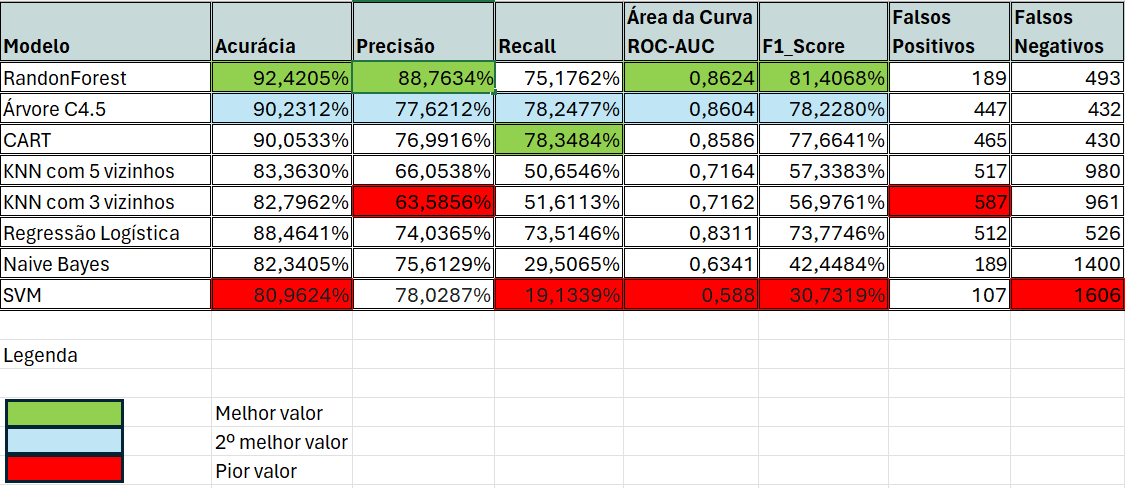


2) execução em 11/12/2024:


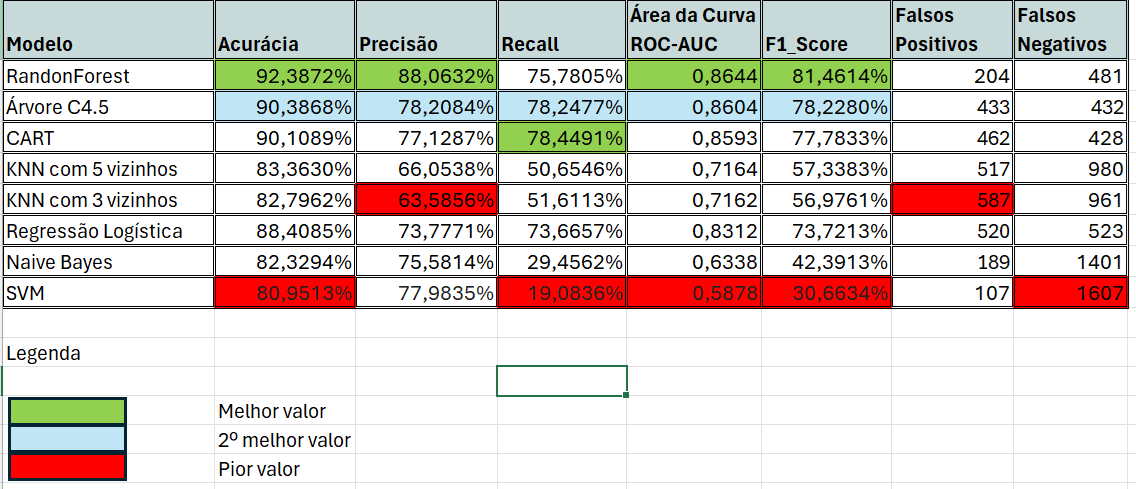



